## Research Questions:
Can we predict the magnitude of earthquakes from historical data?  
Which earthquakes were the largest globally in the past 30 days?
What patterns can be observed from the locations and magnitudes of these earthquakes?

Import libraries

#pip install geopandas matplotlib contextily

In [1]:
import folium
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import geopandas as gpd
from math import sqrt
from itertools import combinations
from folium.plugins import HeatMap
import contextily as ctx
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# URL for "All Earthquakes from the Past 30 days" feed
url = 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson'


In [3]:
# Fetch data
response = requests.get(url)
data = response.json()

# Parse data into a list of dictionaries, each representing an earthquake
earthquakes = []
for feature in data['features']:
    quake = {
        'id': feature['id'],
        'place': feature['properties']['place'],
        'magnitude': feature['properties']['mag'],
        'time': pd.to_datetime(feature['properties']['time'], unit='ms'),
        'latitude': feature['geometry']['coordinates'][1],
        'longitude': feature['geometry']['coordinates'][0],
        'depth': feature['geometry']['coordinates'][2]
    }
    earthquakes.append(quake)


In [4]:
# Convert list of dictionaries 
df_earthquakes = pd.DataFrame(earthquakes)

In [5]:
display(df_earthquakes.head())

,id,place,magnitude,time,latitude,longitude,depth
0,ci40685824,"21 km E of Little Lake, CA",1.32,2024-03-11 23:10:20.250,35.934666,-117.672669,2.71
1,nc74015956,"6 km W of Cobb, CA",0.86,2024-03-11 23:10:14.650,38.829498,-122.796166,0.59
2,ak02439swm7p,"85 km NW of Karluk, Alaska",0.90,2024-03-11 23:09:36.212,58.159500,-155.362200,0.10
3,nc74015951,"6 km WNW of Cobb, CA",0.99,2024-03-11 23:09:00.470,38.833668,-122.794167,0.45
4,nc74015936,"6 km W of Cobb, CA",2.70,2024-03-11 23:07:48.760,38.828834,-122.795334,0.68


In [6]:
df_earthquakes.dtypes

id                   object
place                object
magnitude           float64
time         datetime64[ns]
latitude            float64
longitude           float64
depth               float64
dtype: object

Convert to a readable format 

In [7]:
df_earthquakes['time'] = pd.to_datetime(df_earthquakes['time'], unit='ms')
print("Time column converted to datetime.")

Time column converted to datetime.


Handling Missing Values

In [8]:
# Check for missing values
display(df_earthquakes.isnull().sum())

id           0
place        0
magnitude    1
time         0
latitude     0
longitude    0
depth        0
dtype: int64

In [9]:
if df_earthquakes['magnitude'].isnull().sum() > 0:
    df_earthquakes['magnitude'].fillna(df_earthquakes['magnitude'].median(), inplace=True)
    print("Missing 'magnitude' values filled with median.")
else:
    print("No missing 'magnitude' values to fill.")

Missing 'magnitude' values filled with median.


Remove Uncessessary Columns

In [10]:
#'id' is not needed for the analysis
df_earthquakes.drop('id', axis=1, inplace=True)
print("Unnecessary columns removed.")

Unnecessary columns removed.


Reset Index

In [11]:
df_earthquakes.reset_index(drop=True, inplace=True)
print("Index reset.")

Index reset.


the count of earthquake events organized by their location (properties.place)

In [13]:
df = pd.json_normalize(data['features'])

# Extracting the 'properties.place' column correctly this time
places = df['properties.place']

# Counting occurrences of each place using pandas value_counts() for simplicity
place_counts = places.value_counts()

# Converting the Series to a DataFrame for better visualization
place_counts_df = place_counts.reset_index()
place_counts_df.columns = ['Place', 'Count']

# Sorting the DataFrame by count in descending order to see the most frequent locations
place_counts_df = place_counts_df.sort_values(by='Count', ascending=False).reset_index(drop=True)

# Display the first few rows of the sorted DataFrame
place_counts_df.head()

,Place,Count
0,"14 km NE of Milford, Utah",365
1,"15 km NE of Milford, Utah",233
2,"8 km NW of The Geysers, CA",204
3,"7 km NW of The Geysers, CA",203
4,"11 km NNW of Virginia City, Nevada",82


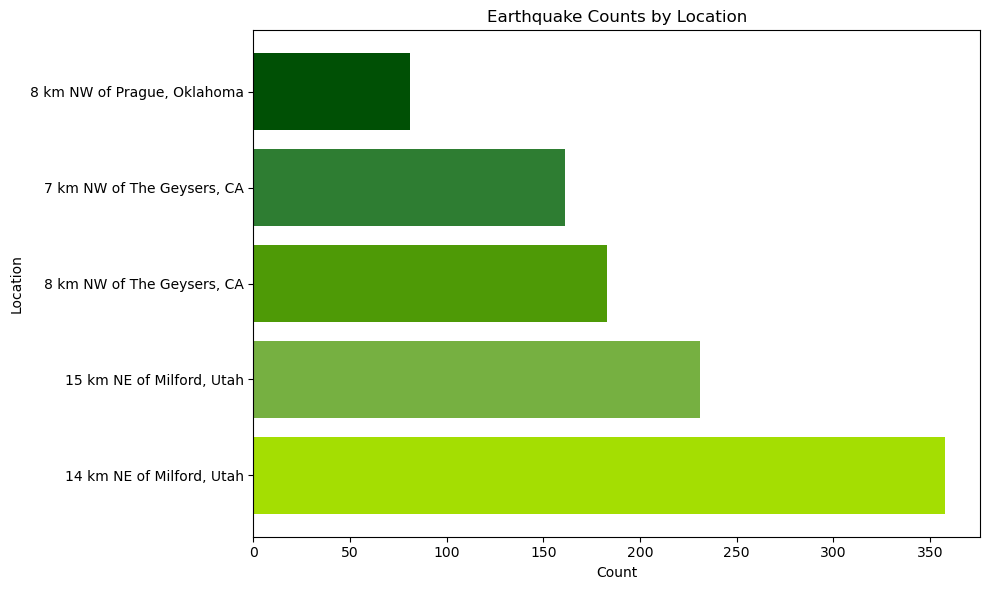

In [14]:
place_counts_df = pd.DataFrame({
    'Place': ["14 km NE of Milford, Utah", "15 km NE of Milford, Utah", "8 km NW of The Geysers, CA", "7 km NW of The Geysers, CA", "8 km NW of Prague, Oklahoma"],
    'Count': [358, 231, 183, 161, 81]
})

# Define a list of shades of green
green_shades = ['#a4de02', '#76b041', '#4e9a06', '#2e7d32', '#005005']

# Plotting
plt.figure(figsize=(10, 6), facecolor='white')
plt.barh(place_counts_df['Place'], place_counts_df['Count'], color=green_shades)
plt.xlabel('Count')
plt.ylabel('Location')
plt.title('Earthquake Counts by Location')
plt.tight_layout()

# save plot
# plt.savefig('earthquake_counts_by_location.png')
# plt.close()

In [19]:
# Displaying top 10 locations with the highest earthquake counts
place_counts_df.head(10)

,Place,Count
0,"14 km NE of Milford, Utah",358
1,"15 km NE of Milford, Utah",231
2,"8 km NW of The Geysers, CA",183
3,"7 km NW of The Geysers, CA",161
4,"8 km NW of Prague, Oklahoma",81


Time Series Analysis of Earthquake Events for the top locations

In [15]:
milford_utah_14km = df_earthquakes[df_earthquakes['properties.place'] == '14 km NE of Milford, Utah']

# Convert the time from Unix timestamp to datetime
milford_utah_14km['time_converted'] = pd.to_datetime(milford_utah_14km['properties.time'], unit='ms')

# Aggregate the data by day
milford_utah_14km_daily = milford_utah_14km.resample('D', on='time_converted').size()

# Plotting the time series
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(milford_utah_14km_daily.index, milford_utah_14km_daily, label='14 km NE of Milford, Utah')
plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.title('Daily Earthquake Frequency')
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'properties.place'

Distribution of Earthquakess magnitude and depths

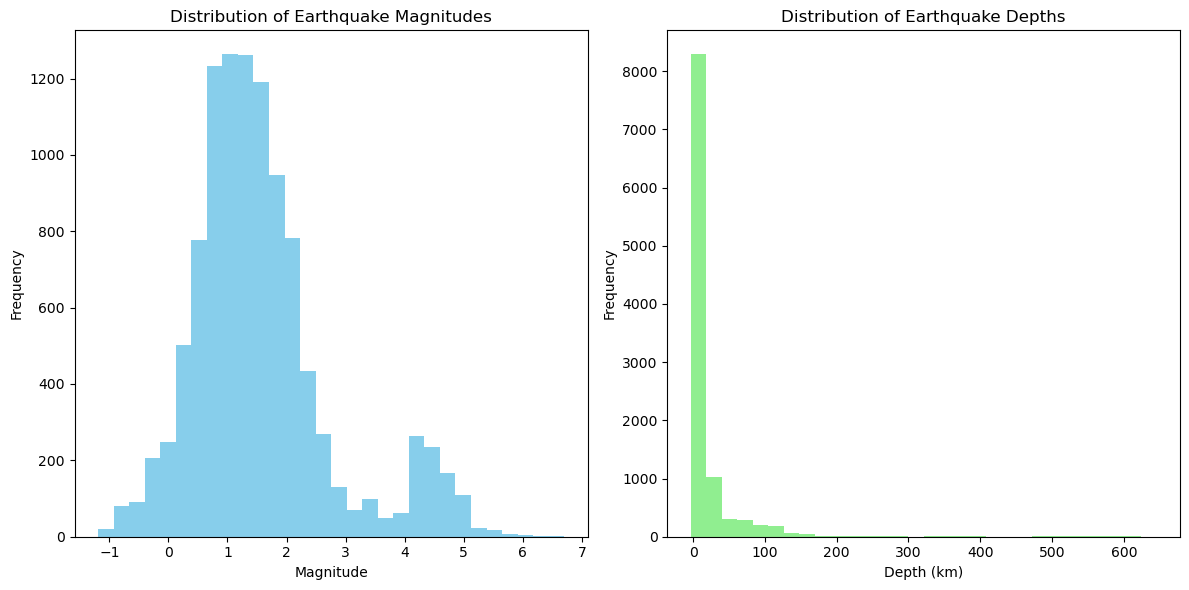

In [16]:
magnitude_column = 'magnitude'
depth_column = 'depth'

plt.figure(figsize=(12, 6), facecolor='white')

# Magnitude Distribution
plt.subplot(1, 2, 1)
plt.hist(df_earthquakes[magnitude_column], bins=30, color='skyblue')
plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')

# Depth Distribution
plt.subplot(1, 2, 2)
plt.hist(df_earthquakes[depth_column], bins=30, color='lightgreen')
plt.title('Distribution of Earthquake Depths')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


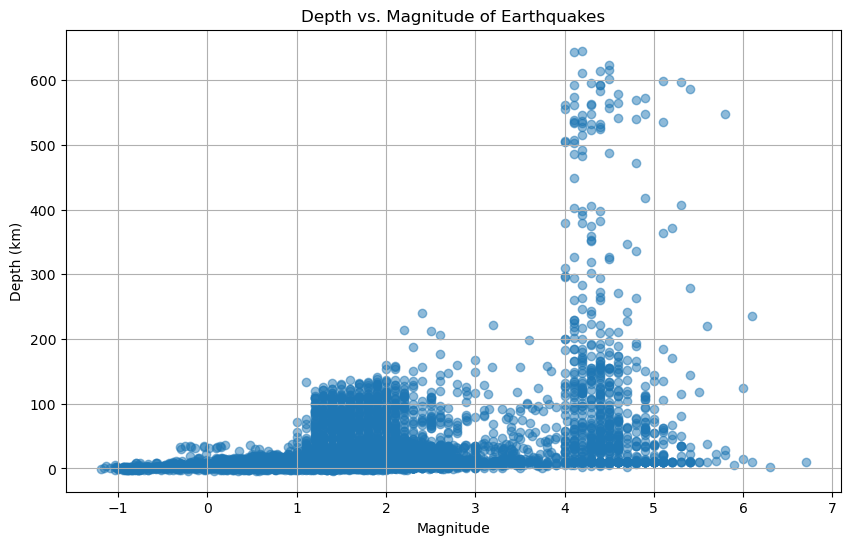

In [17]:
df_earthquakes = pd.DataFrame(earthquakes)  


magnitude_column = 'magnitude'
depth_column = 'depth'
latitude_column = 'latitude'
longitude_column = 'longitude'

# Depth vs. Magnitude Scatter Plot
plt.figure(figsize=(10, 6), facecolor='white')
plt.scatter(df_earthquakes[magnitude_column], df_earthquakes[depth_column], alpha=0.5)
plt.title('Depth vs. Magnitude of Earthquakes')
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.grid(True)
plt.show()



In [18]:
# Geographical Heatmap

# map centered at an average location
map_center = [df_earthquakes[latitude_column].mean(), df_earthquakes[longitude_column].mean()]
map = folium.Map(location=map_center, zoom_start=5)

heat_data = [[row[latitude_column], row[longitude_column]] for index, row in df_earthquakes.iterrows()]
HeatMap(heat_data).add_to(map)

map


In [ ]:
# Save the map as an HTML file
#map.save('earthquake_heatmap.html')
#print('Depth vs. Magnitude Scatter Plot and Geographical Heatmap generated.')

Histogram of Earthquake Frequency

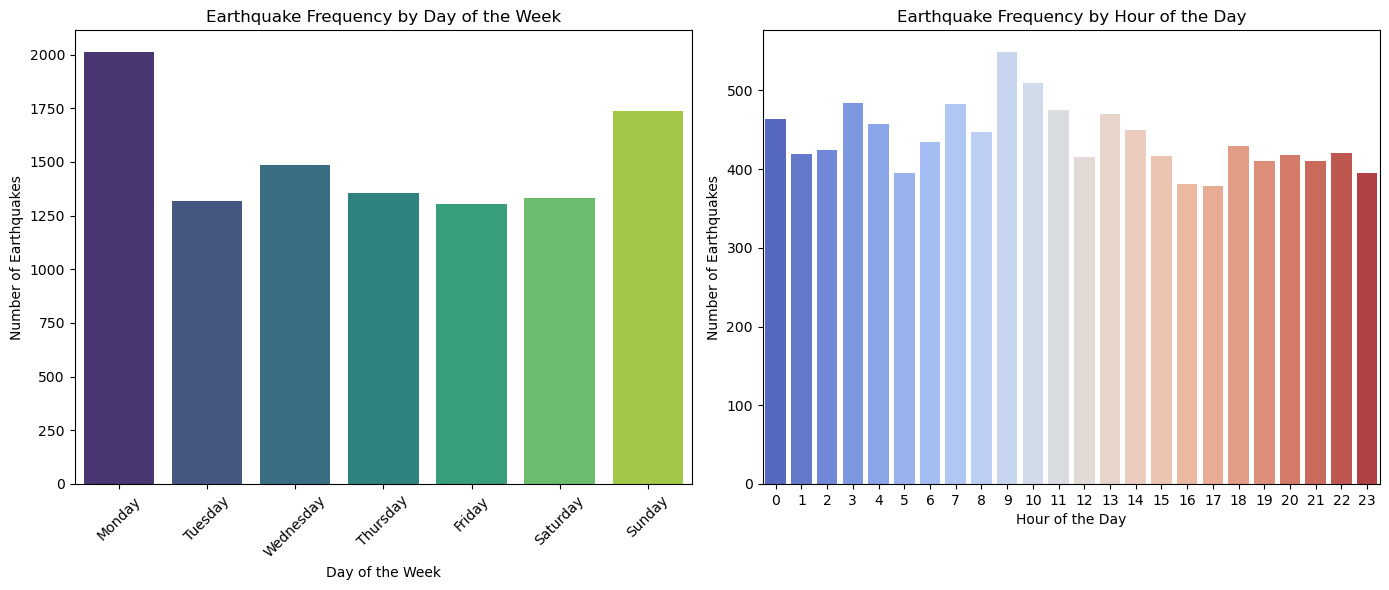

In [21]:
df_earthquakes['time'] = pd.to_datetime(df_earthquakes['time'])

# Creating columns for day of the week and hour of the day
df_earthquakes['day_of_week'] = df_earthquakes['time'].dt.day_name()
df_earthquakes['hour_of_day'] = df_earthquakes['time'].dt.hour

plt.figure(figsize=(14, 6), facecolor='white')

# Day of the Week Analysis
plt.subplot(1, 2, 1)
sns.countplot(x='day_of_week', data=df_earthquakes, palette='viridis', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Earthquake Frequency by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=45)

# Hour of the Day Analysis
plt.subplot(1, 2, 2)
sns.countplot(x='hour_of_day', data=df_earthquakes, palette='coolwarm')
plt.title('Earthquake Frequency by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Earthquakes')

plt.tight_layout()
plt.show()


In [22]:
print(df_earthquakes.columns)


Index(['id', 'place', 'magnitude', 'time', 'latitude', 'longitude', 'depth',
       'day_of_week', 'hour_of_day'],
      dtype='object')


In [23]:
print(df_earthquakes.describe())

          magnitude      latitude     longitude         depth   hour_of_day
count  10539.000000  10540.000000  10540.000000  10540.000000  10540.000000
mean       1.554569     38.788928   -113.133127     21.386151     11.233112
std        1.186993     17.901188     62.427818     52.413605      6.825577
min       -1.190000    -63.702600   -179.881100     -3.480000      0.000000
25%        0.790000     33.167792   -148.878575      2.420000      5.000000
50%        1.350000     38.789417   -121.699333      7.381600     11.000000
75%        2.000000     51.544900   -112.899667     15.000000     17.000000
max        6.700000     85.403300    179.989400    645.729000     23.000000


In [24]:
# Correlation Matrix
print(df_earthquakes.corr())


             magnitude  latitude  longitude     depth  hour_of_day
magnitude     1.000000 -0.495079   0.545639  0.420007     0.004543
latitude     -0.495079  1.000000  -0.454155 -0.244988     0.010705
longitude     0.545639 -0.454155   1.000000  0.162564    -0.005014
depth         0.420007 -0.244988   0.162564  1.000000     0.007235
hour_of_day   0.004543  0.010705  -0.005014  0.007235     1.000000


/var/folders/29/gn_9k02539515njtq6v8rrlm0000gn/T/ipykernel_72687/4222505482.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(df_earthquakes.corr())


In [25]:
unique_places = df_earthquakes['place'].unique()
display(unique_places)


array(['21 km E of Little Lake, CA', '6 km W of Cobb, CA',
       '85 km NW of Karluk, Alaska', ..., '47 km W of Tyonek, Alaska',
       '3 km N of Reno, Nevada', '11 km NNE of Pāhala, Hawaii'],
      dtype=object)

In [26]:
from scipy.stats import ttest_ind

# Selecting two places for comparison
place1 = '3 km ESE of El Centro, CA'
place2 = '6 km NW of The Geysers, CA'

# Filter magnitudes for selected places
group1_magnitudes = df_earthquakes[df_earthquakes['place'] == place1]['magnitude']
group2_magnitudes = df_earthquakes[df_earthquakes['place'] == place2]['magnitude']

# t-test
t_stat, p_value = ttest_ind(group1_magnitudes, group2_magnitudes, nan_policy='omit')  # 'omit' handles any NaNs in the data

# Display t-test results
print(f'T-test between earthquakes in {place1} and {place2}:')
print(f'T-statistic: {t_stat}, P-value: {p_value}')



T-test between earthquakes in 3 km ESE of El Centro, CA and 6 km NW of The Geysers, CA:
T-statistic: nan, P-value: nan


In [29]:

from itertools import combinations


# Get unique places
unique_places = df_earthquakes['place'].unique()

# Generate all possible pairs of unique places
pairs = combinations(unique_places, 2)

# Prepare a list to store the results
results = []

# Perform t-test for each pair and store the results
for place1, place2 in pairs:
    group1 = df_earthquakes[df_earthquakes['place'] == place1]['magnitude']
    group2 = df_earthquakes[df_earthquakes['place'] == place2]['magnitude']
    
    # Perform t-test, omitting NaN values
    t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')
    
    # Append the results to the list
    results.append({'Place 1': place1, 'Place 2': place2, 'T-statistic': t_stat, 'P-value': p_value})

# Convert the results list to a DataFrame for better visualization
results_df = pd.DataFrame(results)



/var/folders/29/gn_9k02539515njtq6v8rrlm0000gn/T/ipykernel_72687/1746278654.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')


In [30]:
# Display the results DataFrame
display(results_df)

,Place 1,Place 2,T-statistic,P-value
0,"21 km E of Little Lake, CA","6 km W of Cobb, CA",1.192018,0.237656
1,"21 km E of Little Lake, CA","85 km NW of Karluk, Alaska",2.822529,0.013565
2,"21 km E of Little Lake, CA","6 km WNW of Cobb, CA",1.520748,0.13349
3,"21 km E of Little Lake, CA","51 km N of Petersville, Alaska",-2.171972,0.118237
4,"21 km E of Little Lake, CA","8 km NW of The Geysers, CA",1.927991,0.055238
...,...,...,...,...
14680066,"241 km W of Adak, Alaska","3 km N of Reno, Nevada",NaN,NaN
14680067,"241 km W of Adak, Alaska","11 km NNE of Pāhala, Hawaii",NaN,NaN
14680068,"47 km W of Tyonek, Alaska","3 km N of Reno, Nevada",NaN,NaN
14680069,"47 km W of Tyonek, Alaska","11 km NNE of Pāhala, Hawaii",NaN,NaN


Filter based on magnitude

In [ ]:
filtered_by_magnitude = df_earthquakes[df_earthquakes['magnitude'] > 5.0]
print(filtered_by_magnitude.head())

Filter based on location

In [ ]:
filtered_by_location = df_earthquakes[df_earthquakes['place'].str.contains("California", case=False)]
print(filtered_by_location.head())

Combining filters 

In [ ]:
combined_filter = df_earthquakes[(df_earthquakes['magnitude'] > 5.0) & (df_earthquakes['place'].str.contains("California", case=False))]
print(combined_filter.head())

Temporal Distribution

In [ ]:
df_earthquakes['date'] = df_earthquakes['time'].dt.date
print(df_earthquakes.groupby('date').size())

Seasonality and Historical Frequencies

Extracting Month and Year

In [ ]:
df_earthquakes['year'] = df_earthquakes['time'].dt.year
df_earthquakes['month'] = df_earthquakes['time'].dt.month

In [ ]:
print(df_earthquakes.head())

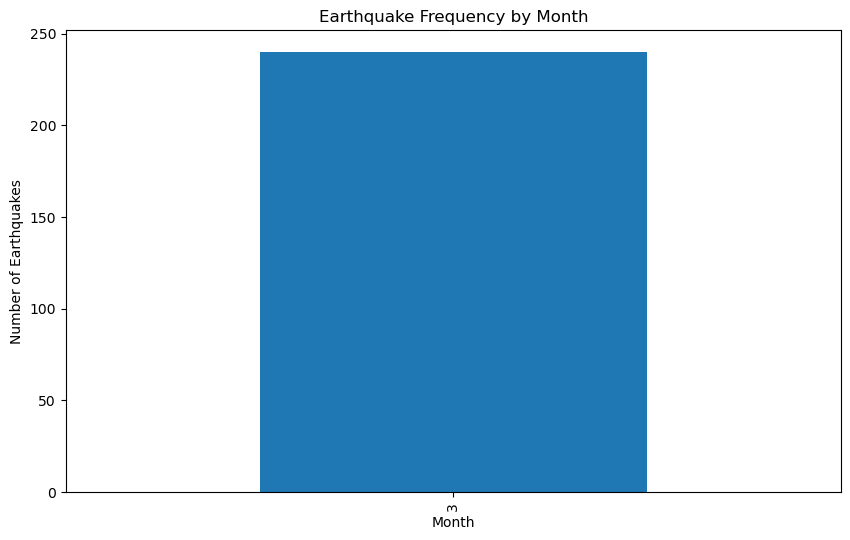

In [30]:
plt.figure(figsize=(10, 6), facecolor='white')
df_earthquakes.groupby('month').size().plot(kind='bar')
plt.title('Earthquake Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Number of Earthquakes')
plt.show()

Correlation Analysis

Correlation with Seasonal Variables

In [ ]:
#dictionary mapping month numbers to seasons
seasons_dict = {
    1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall',
    12: 'Winter'
}

#DataFrame from the dictionary
df_seasonal = pd.DataFrame(list(seasons_dict.items()), columns=['month', 'season'])


In [ ]:

print("Seasonal DataFrame created.")
print(df_seasonal.head())

In [ ]:
# Assuming 'time' column exists and is in datetime format
df_earthquakes['year'] = df_earthquakes['time'].dt.year
df_earthquakes['month'] = df_earthquakes['time'].dt.month

print("Year and month columns added to df_earthquakes.")

In [ ]:
df_merged = pd.merge(df_earthquakes, df_seasonal, on='month', how='left')

print("DataFrames merged.")
print(df_merged.head())

Bar Graphs for Earthquake Frequency by Season

In [ ]:
# 'season' column in df_merged must be created
earthquake_counts_by_season = df_merged['season'].value_counts()

plt.figure(figsize=(10, 6), facecolor='white')
earthquake_counts_by_season.plot(kind='bar', color='skyblue')
plt.title('Earthquake Frequency by Season')
plt.xlabel('Season')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=45)
plt.show()

 Box Plots for Earthquake Magnitude by Season

In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
sns.boxplot(x='season', y='magnitude', data=df_merged)
plt.title('Earthquake Magnitude Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Magnitude')
plt.xticks(rotation=45)
plt.show()

Visualizing Earth Quake Frequencies Overtime

In [ ]:
#date column to datetime format
df_earthquakes['date'] = pd.to_datetime(df_earthquakes['date'])

df_earthquakes['month_year'] = df_earthquakes['date'].dt.to_period('M')

earthquake_counts = df_earthquakes.groupby('month_year').size()

#earthquake counts over time

plt.figure(figsize=(12, 6), facecolor='white')
earthquake_counts.plot(kind='bar')
plt.title('Earthquake Counts Over Time')
plt.xlabel('Month and Year')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=45)
plt.show()

Step 2: Analyze Earthquake Magnitude and Depth by Season

In [ ]:
# Convert the DataFrame to a GeoDataFrame
gdf_earthquakes = gpd.GeoDataFrame(df_earthquakes, geometry=gpd.points_from_xy(df_earthquakes.longitude, df_earthquakes.latitude))

# Set the coordinate reference system (CRS) to WGS84
gdf_earthquakes.crs = "EPSG:4326"

# Convert to Web Mercator for mapping with contextily
gdf_earthquakes = gdf_earthquakes.to_crs(epsg=3857)

# Plotting
fig, ax = plt.subplots(figsize=(10, 10), facecolor='white')
gdf_earthquakes.plot(ax=ax, color='purple', markersize=5)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
plt.title('Earthquake Locations')
plt.show()

North America

In [ ]:
plt.figure(figsize=(10, 10), facecolor='white')

#plot
ax = plt.subplot(1, 1, 1)

# Plot the earthquake data
gdf_earthquakes.plot(ax=ax, color='red', markersize=5)

# Set the geographical extent to North America
ax.set_xlim([-170, -50])  # Longitude limits
ax.set_ylim([15, 70])     # Latitude limits

# basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.title('Earthquake Locations in North America')
plt.show()

<Figure size 1000x1000 with 0 Axes>

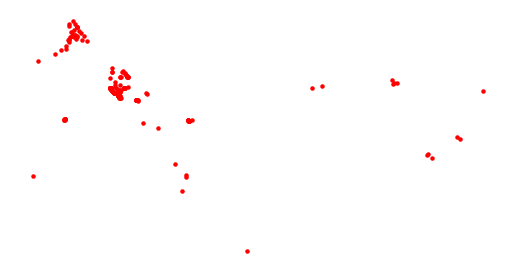

In [52]:
plt.figure(figsize=(10, 10), facecolor='white')
ax = gdf_earthquakes.plot(marker='o', color='red', markersize=5)
ax.set_axis_off()
plt.show()

Create interactive map

In [72]:
!pip install folium==0.12.1

  Obtaining dependency information for folium==0.12.1 from https://files.pythonhosted.org/packages/c3/83/e8cb37afc2f016a1cf4caab8d22caf7fe4156c4c15230d8abc9c83547e0c/folium-0.12.1-py2.py3-none-any.whl.metadata
  Obtaining dependency information for branca>=0.3.0 from https://files.pythonhosted.org/packages/17/ce/14166d0e273d12065516625fb02426350298e7b4ba59198b5fe454b46202/branca-0.7.1-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 1.8 MB/s eta 0:00:00a 0:00:01


In [ ]:
map = folium.Map(location=[20, 0], zoom_start=2, tiles='OpenStreetMap')

#Loop 
for index, row in df_earthquakes.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['magnitude'] * 2,  # Example: scale radius by magnitude for visualization
        popup=f"Magnitude: {row['magnitude']}\nDepth: {row['depth']}",
        color='red',
        fill=True,
        fill_color='red'
    ).add_to(map)


In [ ]:
# Display the map
map

Largest earth Quakes in past 30 days: 

In [ ]:
#significant earthquakes in the past 30 days
url = 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/significant_month.geojson'

# Fetch the data
response = requests.get(url)
data = response.json()

# Extract earthquake data
earthquakes = data['features']

# Parse earthquake data into a DataFrame
rows = []
for eq in earthquakes:
    magnitude = eq['properties']['mag']
    latitude = eq['geometry']['coordinates'][1]
    longitude = eq['geometry']['coordinates'][0]
    rows.append({'magnitude': magnitude, 'latitude': latitude, 'longitude': longitude})

df_earthquakes = pd.DataFrame(rows)


In [ ]:
df_earthquakes.head()

Largest earthQuakes by magnitude

In [ ]:
# Sort by magnitude in descending order and select the top 5
largest_earthquakes = df_earthquakes.sort_values(by='magnitude', ascending=False).head(5)

#top 5 largest earthquakes
print(largest_earthquakes)

In [ ]:
map = folium.Map(location=[20, 0], zoom_start=2, tiles='OpenStreetMap')

#markers for the top 5 largest earthquakes
for index, row in largest_earthquakes.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Magnitude: {row['magnitude']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(map)

#the map to an HTML file
map.save('largest_earthquakes_map.html')

'largest_earthquakes_map.html'

In [ ]:
# Feature selection: Selecting relevant features for the model
X = df_earthquakes[['latitude', 'longitude', 'depth']]  # Input features
y = df_earthquakes['magnitude']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#model
model = LinearRegression()

#
model.fit(X_train, y_train)

In [ ]:
# Predicting the magnitudes on the test
y_pred = model.predict(X_test)

#Root Mean Squared Error (RMSE)
rmse = sqrt(mean_squared_error(y_test, y_pred))

print(f'Root Mean Squared Error: {rmse}')

In [ ]:
#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#model
ridge_model = Ridge()

#parameters grid
parameters = {'alpha': [1e-15, 1e-10, 1e-5, 1, 5, 10, 20]}

#grid search
ridge_regressor = GridSearchCV(ridge_model, parameters, scoring='neg_mean_squared_error', cv=5)
ridge_regressor.fit(X_train, y_train)

# Best parameters& RMSE
print(f'Best Parameters: {ridge_regressor.best_params_}')
best_rmse = sqrt(-ridge_regressor.best_score_)
print(f'Best RMSE: {best_rmse}')